# GROUP PROJECT

**IMPORTANT from classes**
* image size 4k+ !! iterate through all the images to find the biggest (open 1 image -> save the size in a list -> close the image) find Biggest and Smallest
* some images have scale 0-255, some have different
* train test split to loders, validation split inside the model
* make sure not to import not images
* mb exploration only on the train?

* to remove shit data create 3 folds and record on what photos model fails - they are the condidats to be removed
* try ebmedinng model and find outliers in that space for each cluster
* mb try base models from hugging face (i hope we can)



## Importing libraries and setting up google drive

In [1]:
#
import numpy as np
import pandas as pd

# Data visualisation
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

#
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report

#
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import L1, L2
#
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam, SGD, Adagrad, Adadelta, RMSprop
from keras.utils import to_categorical

# cnn related
from keras.layers import Conv2D, Flatten, MaxPooling2D, AveragePooling2D, BatchNormalization

# sort later :3
import tensorflow as tf
import math
from collections import Counter
from PIL import Image as PilImage

# manipulating files
import cv2
from tqdm import tqdm
import os
import ast

# For image showing
from IPython.display import Image, display
import matplotlib.pyplot as plt
import os


In [2]:
directory = 'rare_species/'

In [4]:
# # Set up google drive FOR COLAB
# from google.colab.patches import cv2_imshow
# from google.colab import drive
# drive.mount('/content/drive/')

# # The directory where all the files will go
# !unzip -o "/content/drive/MyDrive/DeepLearningProject/rare_species.zip" -d {directory} > /dev/null # remove all the prints (takes +-2min yo run)

In [7]:
# import torch
# print("CUDA available:", torch.cuda.is_available())
# print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

In [4]:
print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# tf.debugging.set_log_device_placement(True)     # to see which device is being used

In [3]:
metadata = pd.read_csv(f'{directory}metadata.csv')

## Custom functions (later to .py)

In [4]:
def explore_image_files(file_paths, explore_values=False):
    # Define the variables of smalles and biggest images
    image_sizes = []
    color_channels = []
    formats = []
    min_vals = []
    max_vals = []
    ratios = []

    # Iteration loop for each folder to compare the image sizes

    for file_path in file_paths:
        with PilImage.open(file_path) as img:
            image_sizes.append(img.size)
            color_channels.append(img.mode)
            formats.append(img.format)
            ratios.append(img.size[0]/img.size[1])

            if explore_values:
                # Convert to numpy to check the actual data type, Takes alot of time
                img_array = np.array(img)

                # Value range
                min_vals.append(img_array.min())
                max_vals.append(img_array.max())

    if explore_values:
        return image_sizes, color_channels, formats, ratios, min_vals, max_vals
    else:
        return image_sizes, color_channels, formats, ratios

## Initial exploration

### Metadata exploration

#### Basic exploration

In [9]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11983 entries, 0 to 11982
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   rare_species_id  11983 non-null  object
 1   eol_content_id   11983 non-null  int64 
 2   eol_page_id      11983 non-null  int64 
 3   kingdom          11983 non-null  object
 4   phylum           11983 non-null  object
 5   family           11983 non-null  object
 6   file_path        11983 non-null  object
dtypes: int64(2), object(5)
memory usage: 655.4+ KB


In [10]:
metadata.head()

,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family,file_path
0,75fd91cb-2881-41cd-88e6-de451e8b60e2,12853737,449393,animalia,mollusca,unionidae,mollusca_unionidae/12853737_449393_eol-full-si...
1,28c508bc-63ff-4e60-9c8f-1934367e1528,20969394,793083,animalia,chordata,geoemydidae,chordata_geoemydidae/20969394_793083_eol-full-...
2,00372441-588c-4af8-9665-29bee20822c0,28895411,319982,animalia,chordata,cryptobranchidae,chordata_cryptobranchidae/28895411_319982_eol-...
3,29cc6040-6af2-49ee-86ec-ab7d89793828,29658536,45510188,animalia,chordata,turdidae,chordata_turdidae/29658536_45510188_eol-full-s...
4,94004bff-3a33-4758-8125-bf72e6e57eab,21252576,7250886,animalia,chordata,indriidae,chordata_indriidae/21252576_7250886_eol-full-s...


In [11]:
metadata.describe(include='O')

,rare_species_id,kingdom,phylum,family,file_path
count,11983,11983,11983,11983,11983
unique,11983,1,5,202,11983
top,75fd91cb-2881-41cd-88e6-de451e8b60e2,animalia,chordata,cercopithecidae,mollusca_unionidae/12853737_449393_eol-full-si...
freq,1,11983,9952,300,1


In [13]:
# Get phylum counts
phylum_counts = metadata['phylum'].value_counts()

# Calculate number of families per phylum
families_per_phylum = metadata.groupby('phylum')['family'].nunique()

# Create custom hover data with family counts
hover_data = []
for phylum in phylum_counts.index:
    image_count = phylum_counts[phylum]
    family_count = families_per_phylum[phylum]
    percentage = (image_count / len(metadata)) * 100
    hover_data.append([image_count, percentage, family_count])

# Convert to numpy array for easy indexing
hover_data = np.array(hover_data)

# Create figure
fig = go.Figure(go.Bar(
    x=phylum_counts.index,
    y=phylum_counts.values,
    marker=dict(
        color='#6366f1',
        line=dict(color='#4f46e5', width=0.5)
    ),
    text=phylum_counts.values,
    textposition='outside',
    textfont=dict(size=12),
    hovertemplate='<b>%{x}</b><br>' +
                  'Images: %{y}<br>' +
                  'Families: %{customdata[2]}<br>' +
                  'Percentage: %{customdata[1]:.2f}%<extra></extra>',
    customdata=hover_data
))

fig.update_layout(
    title={
        'text': '<b>Distribution of Species by Phylum</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title='Phylum',
    yaxis_title='Count',
    height=600,
    width=1000,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickfont=dict(size=11),
        showgrid=False
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#e5e7eb',
        gridwidth=1
    ),
    font=dict(size=11),
    showlegend=False
)

fig.show()

# Print summary
print("\n" + "="*60)
print("PHYLUM DISTRIBUTION WITH FAMILY COUNTS")
print("="*60)
for phylum in phylum_counts.index:
    image_count = phylum_counts[phylum]
    family_count = families_per_phylum[phylum]
    pct = (image_count / len(metadata)) * 100
    avg_images_per_family = image_count / family_count
    print(f"{phylum:20s}: {image_count:4d} images ({pct:5.2f}%) | {family_count:3d} families | Avg: {avg_images_per_family:.1f} images/family")
print("="*60)


PHYLUM DISTRIBUTION WITH FAMILY COUNTS
chordata            : 9952 images (83.05%) | 166 families | Avg: 60.0 images/family
arthropoda          :  951 images ( 7.94%) |  17 families | Avg: 55.9 images/family
cnidaria            :  810 images ( 6.76%) |  13 families | Avg: 62.3 images/family
mollusca            :  210 images ( 1.75%) |   5 families | Avg: 42.0 images/family
echinodermata       :   60 images ( 0.50%) |   1 families | Avg: 60.0 images/family


In [14]:
# Get all family counts
family_counts = metadata['family'].value_counts()

# Create figure with scrollable y-axis
fig = go.Figure(go.Bar(
    x=family_counts.values,
    y=family_counts.index,
    orientation='h',
    marker=dict(
        color='#6366f1',
        line=dict(color='#4f46e5', width=0.5)
    ),
    text=family_counts.values,
    textposition='outside',
    textfont=dict(size=10),
    hovertemplate='<b>%{y}</b><br>Images: %{x}<br>Percentage: %{customdata:.2f}%<extra></extra>',
    customdata=(family_counts.values / len(metadata)) * 100
))

fig.update_layout(
    title={
        'text': '<b>Distribution Of Species By Family</b><br><sub>All families shown - scroll to explore</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title='Number of Images',
    yaxis_title='Family',
    height=max(1000, len(family_counts) * 15),  # Dynamic height based on number of families
    width=1200,
    plot_bgcolor='white',
    paper_bgcolor='white',
    yaxis=dict(
        autorange='reversed',  # Highest count on top
        tickfont=dict(size=9),
        showgrid=False
    ),
    xaxis=dict(
        showgrid=True,
        gridcolor='#e5e7eb',
        gridwidth=1
    ),
    font=dict(size=11),
    margin=dict(l=200, r=100, t=100, b=50),  # More space for family names
    showlegend=False
)

fig.show()


In [15]:

# Count at each taxonomic level
phylum_to_family = metadata.groupby(['phylum', 'family']).size().reset_index(name='count')

# Prepare data for Sankey
labels = list(metadata['phylum'].unique()) + list(metadata['family'].unique())
label_dict = {label: idx for idx, label in enumerate(labels)}

source = []
target = []
value = []

for _, row in phylum_to_family.iterrows():
    source.append(label_dict[row['phylum']])
    target.append(label_dict[row['family']])
    value.append(row['count'])

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color='#6366f1'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color='rgba(99, 102, 241, 0.3)'
    )
)])

fig.update_layout(
    title='<b>Taxonomic Hierarchy: Phylum → Family</b>',
    font=dict(size=12),
    height=800,
    width=1200
)

fig.show()

print("\n📊 TAXONOMIC DIVERSITY:")
print(f"Phylums: {metadata['phylum'].nunique()}")
print(f"Families: {metadata['family'].nunique()}")
print(f"Average families per phylum: {metadata['family'].nunique() / metadata['phylum'].nunique():.1f}")


📊 TAXONOMIC DIVERSITY:
Phylums: 5
Families: 202
Average families per phylum: 40.4


#### Retracting more information from the images

In [5]:
# # Extract more information about the images and save to the metadata df (6min)
# metadata['image_size'], metadata['color_channel'], metadata['format'], metadata['aspect_ratio'], \
# metadata['min_val'], metadata['max_val'] = explore_image_files(directory + metadata['file_path'], explore_values=True)

# Don't explore values to save time (1min)
metadata['image_size'], metadata['color_channel'], metadata['format'], metadata['aspect_ratio'] = explore_image_files(directory + metadata['file_path'])

c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [6]:
metadata['width'], metadata['height'] = zip(*metadata['image_size'])

In [7]:
metadata.describe()

,eol_content_id,eol_page_id,aspect_ratio,width,height
count,1.198300e+04,1.198300e+04,11983.000000,11983.000000,11983.000000
mean,2.297681e+07,2.112247e+07,1.332127,1924.600935,1512.260285
std,6.999289e+06,2.241319e+07,0.396398,1267.575315,951.330175
min,4.750000e+02,1.180080e+05,0.199919,170.000000,125.000000
25%,2.058937e+07,7.954560e+05,1.247341,1000.000000,768.000000
50%,2.251368e+07,2.865857e+06,1.333333,1784.000000,1365.000000
75%,2.932887e+07,4.551773e+07,1.500366,2048.000000,2013.500000
max,3.061946e+07,5.269200e+07,7.534247,17000.000000,8688.000000


huge file at "\rare_species\mollusca_cardiidae\30003931_46473744_eol-full-size-copy.jpg"

In [8]:
# Plot colour channel distribution
color_channel_mapping = {
    'L': 'Greyscale',
    'RGB': 'RGB',
    'RGBA': 'RGBA',
    'P': 'Palette',
    'CMYK': 'CMYK',
    '1': 'Binary',
    'LA': 'Greyscale + Alpha'
}

# Get value counts and map to readable names
color_counts = metadata['color_channel'].value_counts()
color_counts.index = color_counts.index.map(lambda x: color_channel_mapping.get(x, x))

# Create figure
fig = go.Figure(go.Bar(
    x=color_counts.index,
    y=color_counts.values,
    marker=dict(
        color='#6366f1',
        line=dict(color='#4f46e5', width=0.5)
    ),
    text=color_counts.values,
    textposition='outside',
    textfont=dict(size=12),
    hovertemplate='<b>%{x}</b><br>Images: %{y}<br>Percentage: %{customdata:.2f}%<extra></extra>',
    customdata=(color_counts.values / len(metadata)) * 100
))

fig.update_layout(
    title={
        'text': '<b>Distribution Of Colour Channels</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title='Color Channel',
    yaxis_title='Count',
    height=600,
    width=1000,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickfont=dict(size=11),
        showgrid=False
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#e5e7eb',
        gridwidth=1
    ),
    font=dict(size=11),
    showlegend=False
)

fig.show()

In [9]:
# Custom lines based on previous discoveries
common_ratio = 4/3
width_max = 500        # MB CHANGE LATER

In [10]:
# Create figure with custom styling
fig = go.Figure()

# Add scatter plot with better styling
fig.add_trace(go.Scatter(
    x=metadata['width'],
    y=metadata['height'],
    mode='markers',
    marker=dict(
        size=4,
        color='#6366f1',
        opacity=0.4,
        line=dict(width=0)
    ),
    name='Images',
    hovertemplate='<b>Width:</b> %{x}px<br><b>Height:</b> %{y}px<extra></extra>'
))

# Add aspect ratio reference line (4:3)
max_y = metadata['height'].max()
max_x_for_ratio = common_ratio * max_y
fig.add_trace(go.Scatter(
    x=[0, max_x_for_ratio],
    y=[0, max_y],
    mode='lines',
    line=dict(color='#ef4444', width=2.5, dash='dash'),
    name='4:3 Aspect Ratio',
    hoverinfo='skip'
))

# Add width threshold line
fig.add_trace(go.Scatter(
    x=[width_max, width_max],
    y=[0, max_y],
    mode='lines',
    line=dict(color='#10b981', width=2.5, dash='dash'),
    name=f'Max Width ({width_max}px)',
    hoverinfo='skip'
))

# Update layout with legend on the right and bold title
fig.update_layout(
    title={
        'text': '<b>Image Size Distribution Analysis</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 22, 'color': '#1f2937'}
    },
    xaxis=dict(
        title='Width (pixels)',
        showgrid=True,
        gridcolor='#e5e7eb',
        gridwidth=1,
        zeroline=False,
        title_font=dict(size=14, color='#374151')
    ),
    yaxis=dict(
        title='Height (pixels)',
        showgrid=True,
        gridcolor='#e5e7eb',
        gridwidth=1,
        zeroline=False,
        title_font=dict(size=14, color='#374151')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=700,
    showlegend=True,
    legend=dict(
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.95)',
        bordercolor='#d1d5db',
        borderwidth=1,
        font=dict(size=11)
    ),
    hovermode='closest'
)

fig.show()

# Enhanced summary statistics
image_size = (width_max, round(width_max/common_ratio))
print(f'\n{"="*50}')
print(f'📊 RECOMMENDED IMAGE SIZE: {image_size[0]}x{image_size[1]}')
print(f'{"="*50}')
print(f'   Aspect Ratio: {common_ratio:.2f}:1 (4:3)')
print(f'   Total Images: {len(metadata):,}')
print(f'   Width Range: {metadata["width"].min()}-{metadata["width"].max()}px')
print(f'   Height Range: {metadata["height"].min()}-{metadata["height"].max()}px')
print(f'{"="*50}\n')


📊 RECOMMENDED IMAGE SIZE: 500x375
   Aspect Ratio: 1.33:1 (4:3)
   Total Images: 11,983
   Width Range: 170-17000px
   Height Range: 125-8688px



In [11]:
# Create 2D histogram/heatmap of image dimensions
fig = px.density_heatmap(
    metadata,
    x='width',
    y='height',
    nbinsx=50,
    nbinsy=50,
    title='<b>Image Dimension Density Heatmap</b>',
    labels={'width': 'Width (pixels)', 'height': 'Height (pixels)'},
    color_continuous_scale='Blues'
)

fig.update_layout(
    width=900,
    height=700,
    plot_bgcolor='white'
)

fig.show()

### Images exploration

#### All images

In [ ]:
# Print 5 example images of each class (+-3min)
for label in os.listdir(directory):
    path = directory + str(label)

    if not os.path.isdir(path):
        print(f"Directory {path} does not exist.")
        continue

    folder_data = os.listdir(path)
    k = 0
    print(f'{label} ({len(folder_data)} images)')

    # Collect image paths
    image_paths = []
    for image_path in folder_data:
        if k < 5:                                               # <-- change how many images per class
            full_path = os.path.join(path, image_path)
            image_paths.append(full_path)
            k += 1

    # Display images
    if image_paths:
        fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 3))
        if len(image_paths) == 1:
            axes = [axes]

        for ax, img_path in zip(axes, image_paths):
            img = PilImage.open(img_path)
            ax.imshow(img)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

From printing some examples of the images that we'll be working with we can see that we have a few:

- X-ray imagaes
- Images of signs
- Paintings
- Text extracts with no images
- Images unrelated to the class
- Maps
- Varying zoom / color / rotations

#### Grayscale VS CMYK

In [78]:
datagen = ImageDataGenerator(rescale=1./255)

# Get only greyscale images
temp_generator = datagen.flow_from_dataframe(
    dataframe=metadata[metadata.color_channel == 'L'],
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Not shuffling
)

Found 183 validated image filenames belonging to 62 classes.


In [ ]:
# Get class names from the generator
class_names = list(temp_generator.class_indices.keys())

# Determine the total number of batches in the generator
num_batches = int(math.ceil(temp_generator.n / temp_generator.batch_size))

for i in range(num_batches):
    images, labels = next(temp_generator)

    # Plot the images in the current batch
    batch_size_actual = images.shape[0]
    n_cols = min(8, batch_size_actual)                  # <-- set max columns per row
    n_rows = math.ceil(batch_size_actual / n_cols)

    plt.figure(figsize=(3 * n_cols, 3 * n_rows))

    for j in range(batch_size_actual):
        ax = plt.subplot(n_rows, n_cols, j + 1)
        plt.imshow(images[j])

        # Get the index of the highest probability to find the class name
        label_idx = np.argmax(labels[j])
        plt.title(class_names[label_idx], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Some images retain at least the shape of the actual animal, but most of them are really bad

In [81]:
# Do the same for CMYK
temp_generator = datagen.flow_from_dataframe(
    dataframe=metadata[metadata.color_channel == 'CMYK'],
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # Not shuffling
)

Found 178 validated image filenames belonging to 8 classes.


In [ ]:
# Get class names from the generator
class_names = list(temp_generator.class_indices.keys())

# Determine the total number of batches in the generator
num_batches = int(math.ceil(temp_generator.n / temp_generator.batch_size))

for i in range(num_batches):
    images, labels = next(temp_generator)

    # Plot the images in the current batch
    batch_size_actual = images.shape[0]
    n_cols = min(8, batch_size_actual)                  # <-- set max columns per row
    n_rows = math.ceil(batch_size_actual / n_cols)

    plt.figure(figsize=(3 * n_cols, 3 * n_rows))

    for j in range(batch_size_actual):
        ax = plt.subplot(n_rows, n_cols, j + 1)
        plt.imshow(images[j])

        # Get the index of the highest probability to find the class name
        label_idx = np.argmax(labels[j])
        plt.title(class_names[label_idx], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Most of the images apper to be x-rays of sculls of different animals which don't really help identify the animals by the picture, and will more likely only confuse the model. \
(and there are 2 different images for some reason: 2 parrots and a turtle)

In [ ]:
# Delete the generator to free up resources (small impactbut why not)
del temp_generator

## Preprocessing

In [ ]:
# TRY TO ONLY USE RGB
# metadata = metadata[metadata.color_channel == 'RGB'].reset_index(drop=True)

In [ ]:
# good_images_df = good_images_df[good_images_df.family != 'formicidae'].reset_index(drop=True)

In [12]:
# keep this imports here for how cuz we might change the model
from tensorflow.keras.applications import EfficientNetB4    
from tensorflow.keras.applications.efficientnet import preprocess_input

In [13]:
# Load pre-trained EfficientNet without the top classification layer
base_model = EfficientNetB4(weights='imagenet', include_top=False, pooling='avg')

# Create a model that outputs embeddings
embedding_model = Model(inputs=base_model.input, outputs=base_model.output)
print(f"Embedding dimension: {base_model.output_shape[-1]}")

Embedding dimension: 1792


In [14]:
# Create generator with preprocessing form the model
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create generator 
preprocessing_generator = datagen.flow_from_dataframe(
    dataframe=metadata,
    directory=directory,
    x_col='file_path',
    y_col='family',  
    target_size=image_size,
    batch_size=32,  
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False       # Not to mess up the order with df
)


# Generate embeddings
embeddings_list = []

# Calculate number of batches
num_batches = len(preprocessing_generator)

for i in tqdm(range(num_batches)):  #(+-4.5min)
    batch_images, _ = next(preprocessing_generator)  # Get images (ignore labels)
    
    # Generate embeddings
    batch_embeddings = embedding_model.predict(batch_images, verbose=0) 
    embeddings_list.extend(batch_embeddings)

Found 11983 validated image filenames belonging to 202 classes.


 85%|████████▍ | 318/375 [03:35<00:37,  1.51it/s]c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.

100%|██████████| 375/375 [04:13<00:00,  1.48it/s]


In [15]:
# Kill the generator to free up resources (not actually sure that even helps)
del preprocessing_generator

In [16]:
# Add embedings to metadata
metadata['embedding'] = embeddings_list

In [17]:
def distance_to_centroid(metadata):
    # Calculate a centroid for each family
    centroids = {}

    for family in metadata['family'].unique():
        family_embeddings = metadata[
            (metadata['family'] == family) &
            (metadata['embedding'].notna())
        ]['embedding'].tolist()
        

        if len(family_embeddings) > 0:
            # Stack embeddings and calculate mean
            embeddings_array = np.stack(family_embeddings)
            centroids[family] = np.mean(embeddings_array, axis=0)
    

    # Calculate distances to centroids
    distances = []

    for idx, row in metadata.iterrows():
        if pd.isna(row['embedding'].any()):
            distances.append(np.nan)
        else:
            family = row['family']
            if family in centroids:
                # Calculate Euclidean distance
                distance = np.linalg.norm(row['embedding'] - centroids[family])
                distances.append(distance)
            else:
                distances.append(np.nan)
    
    return distances

In [18]:
metadata['distance_to_centroid'] = distance_to_centroid(metadata)

In [19]:
def show_outlier_images(metadata, N):
   # Get the images sorted by distance to centroid (make a copy to not mess up the original metadata)
    sorted_metadata = metadata.sort_values(by='distance_to_centroid', ascending=False).copy()

    # Display the first N images
    n_cols = 10
    n_rows = (N + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
    # Flatten axes to simplify indexing
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
        

    for idx in range(N):
        if idx < len(sorted_metadata):
            img_path = os.path.join(directory, sorted_metadata.iloc[idx]['file_path'])
            img = PilImage.open(img_path)
            axes[idx].imshow(img)
            family = sorted_metadata.iloc[idx]['family']
            axes[idx].set_title(f'{family} (id={idx})', fontsize=8)
            axes[idx].axis('off')

        else:
            # No image for this subplot, hide it
            axes[idx].axis('off')

    # Hide any remaining unused subplots (in case N < n_rows * n_cols)
    for j in range(N, n_rows * n_cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
show_outlier_images(metadata, 300)

In [20]:
threshold = metadata['distance_to_centroid'].quantile(0.95) # top 5% as outliers
outliers = metadata[metadata['distance_to_centroid'] > threshold].copy()
good_images_df = metadata[metadata['distance_to_centroid'] < threshold].copy()

In [21]:
print(f"Found {len(outliers)} outliers")

Found 600 outliers


In [20]:
# good_images_df.drop('distance_to_centroid', axis=1, inplace=True)
# good_images_df['distance_to_centroid'] = distance_to_centroid(good_images_df)

In [21]:
# show_outlier_images(good_images_df, 300)

In [23]:
print(f"Total images after outlier removal: {len(good_images_df)} (out of {len(metadata)})")
print(f"The lowest amount of images per class {good_images_df['family'].value_counts().iloc[-1]} in family '{good_images_df['family'].value_counts().idxmin()}'")

Total images after outlier removal: 11383 (out of 11983)
The lowest amount of images per class 25 in family 'cheloniidae'


In [ ]:
# 2 good images and then outliers
good_images = 2

for family in outliers['family'].unique():
    image_paths = list(directory+good_images_df[good_images_df.family == family]['file_path'])[:good_images]
    image_paths.extend(list(directory+outliers[outliers.family == family]['file_path']))

    if image_paths:
        # Set number of columns and calculate rows needed
        n_cols = 7
        n_images = len(image_paths)
        n_rows = (n_images + n_cols - 1) // n_cols  # Ceiling division

        # Create subplots with appropriate dimensions
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 2 * n_rows))

        # Flatten axes array for easier iteration
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        # Display images
        for idx, img_path in enumerate(image_paths):
            img = PilImage.open(img_path).resize((224, 224), PilImage.LANCZOS)
            axes[idx].imshow(img)
            axes[idx].axis('off')

        # Add green outline for good images (first good_count images)
            if idx < good_images:
                rect = plt.Rectangle((0, 0), 223, 223, fill=False,
                                    edgecolor='lime', linewidth=3)
                axes[idx].add_patch(rect)

        # Hide any unused subplots
        for idx in range(n_images, n_rows * n_cols):
            axes[idx].axis('off')

        plt.suptitle(f"{family}, {good_images_df[good_images_df.family == family].shape[0]} good images left")#, fontsize=16, y=0.9, x=0.1)
        plt.tight_layout()
        plt.show()

### Import the dataset

In [24]:
# Stratified split the metadata to get the paths for the images
train_df, test_df = train_test_split(
  good_images_df,   # use only good images
  test_size=0.1,
  stratify=good_images_df['family'],
  shuffle=True,
  random_state=42
)

train_df, val_df = train_test_split(
  train_df,
  test_size=0.1,
  stratify=train_df['family'],
  shuffle=True,
  random_state=42
)

# Print the final proportions of the split
print(f"Training  : {len(train_df)} ({round(len(train_df)/len(metadata)*100)}%) \
        \nValidation: {len(val_df)} ({round(len(val_df)/len(metadata)*100)}%)  \
        \nTesting   : {len(test_df)} ({round(len(test_df)/len(metadata)*100)}%) \
        \nTotal     : {len(train_df) + len(val_df) + len(test_df)}")

Training  : 9219 (77%)         
Validation: 1025 (9%)          
Testing   : 1139 (10%)         
Total     : 11383


In [25]:
# Create ImageDataGenerator for both train and test
# Transform all the images to the image_size and rgb mode
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)    #rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,     # Transform to found image size
    batch_size=32,
    class_mode='sparse',   # Use sparse for integer labels
    color_mode='rgb',   # Convert all the images to RGB
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='sparse',   # Use sparse for integer labels
    color_mode='rgb',
    shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=directory,
    x_col='file_path',
    y_col='family',
    target_size=image_size,
    batch_size=32,
    class_mode='sparse',   # Use sparse for integer labels
    color_mode='rgb',
    shuffle=False   # !! Not shuffling the test data for reproducibility
)

Found 9219 validated image filenames belonging to 202 classes.
Found 1025 validated image filenames belonging to 202 classes.
Found 1139 validated image filenames belonging to 202 classes.


In [ ]:
# Get a batch of images and labels
images, labels = next(train_generator)

# Get class names
class_names = list(train_generator.class_indices.keys())

# Plot the images
plt.figure(figsize=(12, 8))

for i in range(21):
    ax = plt.subplot(3, 7, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])  # Get actual labele names
    plt.axis("off")

plt.tight_layout()
plt.show()

## Model


### Shit model to try

In [ ]:
# Get number of classes
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")

Number of classes: 202


In [ ]:
# Build CNN Model (1.5h+-)
model = Sequential()
model.add(Input((*image_size, 3)))

# First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Third Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Fourth Convolutional Block
# model.add(Conv2D(256, (3, 3), activation='relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D((2, 2)))

# Flatten and Dense Layers
model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7
)

# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    batch_size=3000,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 269s 862ms/step - accuracy: 0.0139 - loss: 12.2118 - val_accuracy: 0.0222 - val_loss: 5.2619 - learning_rate: 0.0010
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 256s 843ms/step - accuracy: 0.0210 - loss: 5.2756 - val_accuracy: 0.0250 - val_loss: 5.2159 - learning_rate: 0.0010
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 258s 847ms/step - accuracy: 0.0243 - loss: 5.2246 - val_accuracy: 0.0250 - val_loss: 5.1776 - learning_rate: 0.0010
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 251s 827ms/step - accuracy: 0.0277 - loss: 5.1724 - val_accuracy: 0.0195 - val_loss: 5.5622 - learning_rate: 0.0010
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 245s 807ms/step - accuracy: 0.0270 - loss: 5.1368 - val_accuracy: 0.0250 - val_loss: 5.1206 - learning_rate: 0.0010
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 245s 808ms/step - accuracy: 0.0272 - loss: 5.1177 - val_accuracy: 0.0250 - val_loss: 5.1007 - learning_rate: 0.0010
Epoch 7/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 240s 789ms/step - accur

In [ ]:
# ============ EVALUATION ============
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

test_results = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")


FINAL EVALUATION ON TEST SET
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 798ms/step - accuracy: 0.0294 - loss: 5.0015

Test Accuracy: 0.0250
Test Loss: 5.0240


### With keras base model

In [26]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D

In [68]:
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(*image_size, 3) 
)

# Freeze base model initially
base_model.trainable = False

In [56]:
# from focal_loss import SparseCategoricalFocalLoss
from keras import regularizers

In [ ]:
len(set(train_generator.classes)) # -_-

202

In [69]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [70]:
# Build the classifier
with tf.device('/GPU:0'):   # Move the model to gpu
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.4),
        BatchNormalization(),
        Dense(202, kernel_regularizer=regularizers.L2(0.01), activation='softmax')
    ])

In [59]:
# After building your model
print("Total params:", model.count_params())
print("Trainable params:", sum([tf.size(w).numpy() for w in model.trainable_weights]))
print("Non-trainable params:", sum([tf.size(w).numpy() for w in model.non_trainable_weights]))

Total params: 18043177
Trainable params: 365770
Non-trainable params: 17677407


In [71]:
# Compile with categorical crossentropy for multi-class
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',     #SparseCategoricalFocalLoss(gamma=2),           #'sparse_categorical_crossentropy',
    metrics=['accuracy'],                       # 'top_k_categorical_accuracy']          # Top-5 accuracy
)

# Set up callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

# Fit the model
history1 = model.fit(
    train_generator,
    epochs=40,
    batch_size=300,
    class_weight=class_weight_dict,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
226/289 [======================>.......] - ETA: 44s - loss: 4.8370 - accuracy: 0.4647

c:\Users\User\miniforge3\envs\dl\lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning:

Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



289/289 [==============================] - 252s 841ms/step - loss: 4.4612 - accuracy: 0.5021 - val_loss: 2.9428 - val_accuracy: 0.7073 - lr: 0.0010
Epoch 2/40
289/289 [==============================] - 316s 1s/step - loss: 2.2665 - accuracy: 0.7259 - val_loss: 2.1449 - val_accuracy: 0.7590 - lr: 0.0010
Epoch 3/40
289/289 [==============================] - 281s 971ms/step - loss: 1.8420 - accuracy: 0.7559 - val_loss: 1.9907 - val_accuracy: 0.7405 - lr: 0.0010
Epoch 4/40
289/289 [==============================] - 322s 1s/step - loss: 1.6988 - accuracy: 0.7674 - val_loss: 1.9260 - val_accuracy: 0.7502 - lr: 0.0010
Epoch 5/40
289/289 [==============================] - 354s 1s/step - loss: 1.6685 - accuracy: 0.7698 - val_loss: 1.9889 - val_accuracy: 0.7288 - lr: 0.0010
Epoch 6/40
289/289 [==============================] - 397s 1s/step - loss: 1.6725 - accuracy: 0.7685 - val_loss: 1.9673 - val_accuracy: 0.7483 - lr: 0.0010
Epoch 7/40
289/289 [==============================] - 325s 1s/step - 

In [ ]:
# # Fine-tuning the model
# # Unfreeze base model
# base_model.trainable = True

# # Recompile with much lower learning rate
# model.compile(
#     optimizer=Adam(learning_rate=1e-5),  # 100x lower learning rate
#     loss='categorical_crossentropy',
#     metrics=['accuracy', 'top_k_categorical_accuracy']
# )

# history2 = model.fit(
#     train_generator,
#     epochs=20,
#     validation_data=val_generator,
#     callbacks=callbacks,
#     verbose=1
# )

## Results

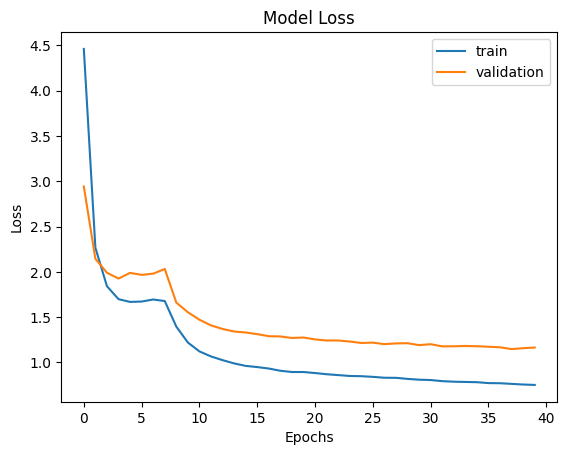

In [72]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

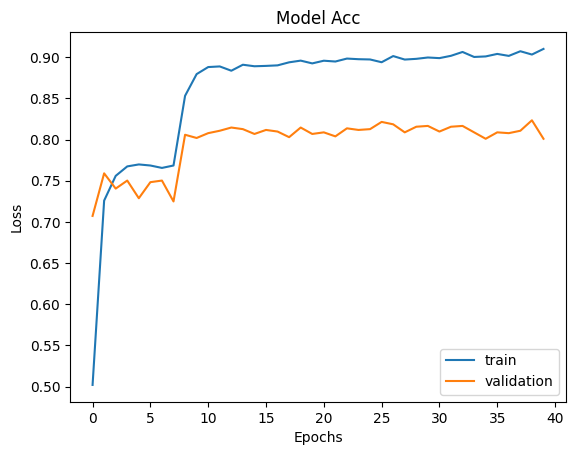

In [73]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model Acc')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [74]:
test_results = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")

36/36 [==============================] - 33s 930ms/step - loss: 1.2023 - accuracy: 0.7867
Test Accuracy: 0.7867
Test Loss: 1.2023


In [75]:
# Get predictions for F1 score
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels
y_true = test_generator.classes

# Calculate F1 scores
f1_micro = f1_score(y_true, y_pred_classes, average='micro')
f1_macro = f1_score(y_true, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true, y_pred_classes, average='weighted')

print(f"\nF1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

#Detailed classification report
# print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

36/36 [==============================] - 31s 768ms/step

F1 Score (Micro): 0.7867
F1 Score (Macro): 0.7788
F1 Score (Weighted): 0.7884


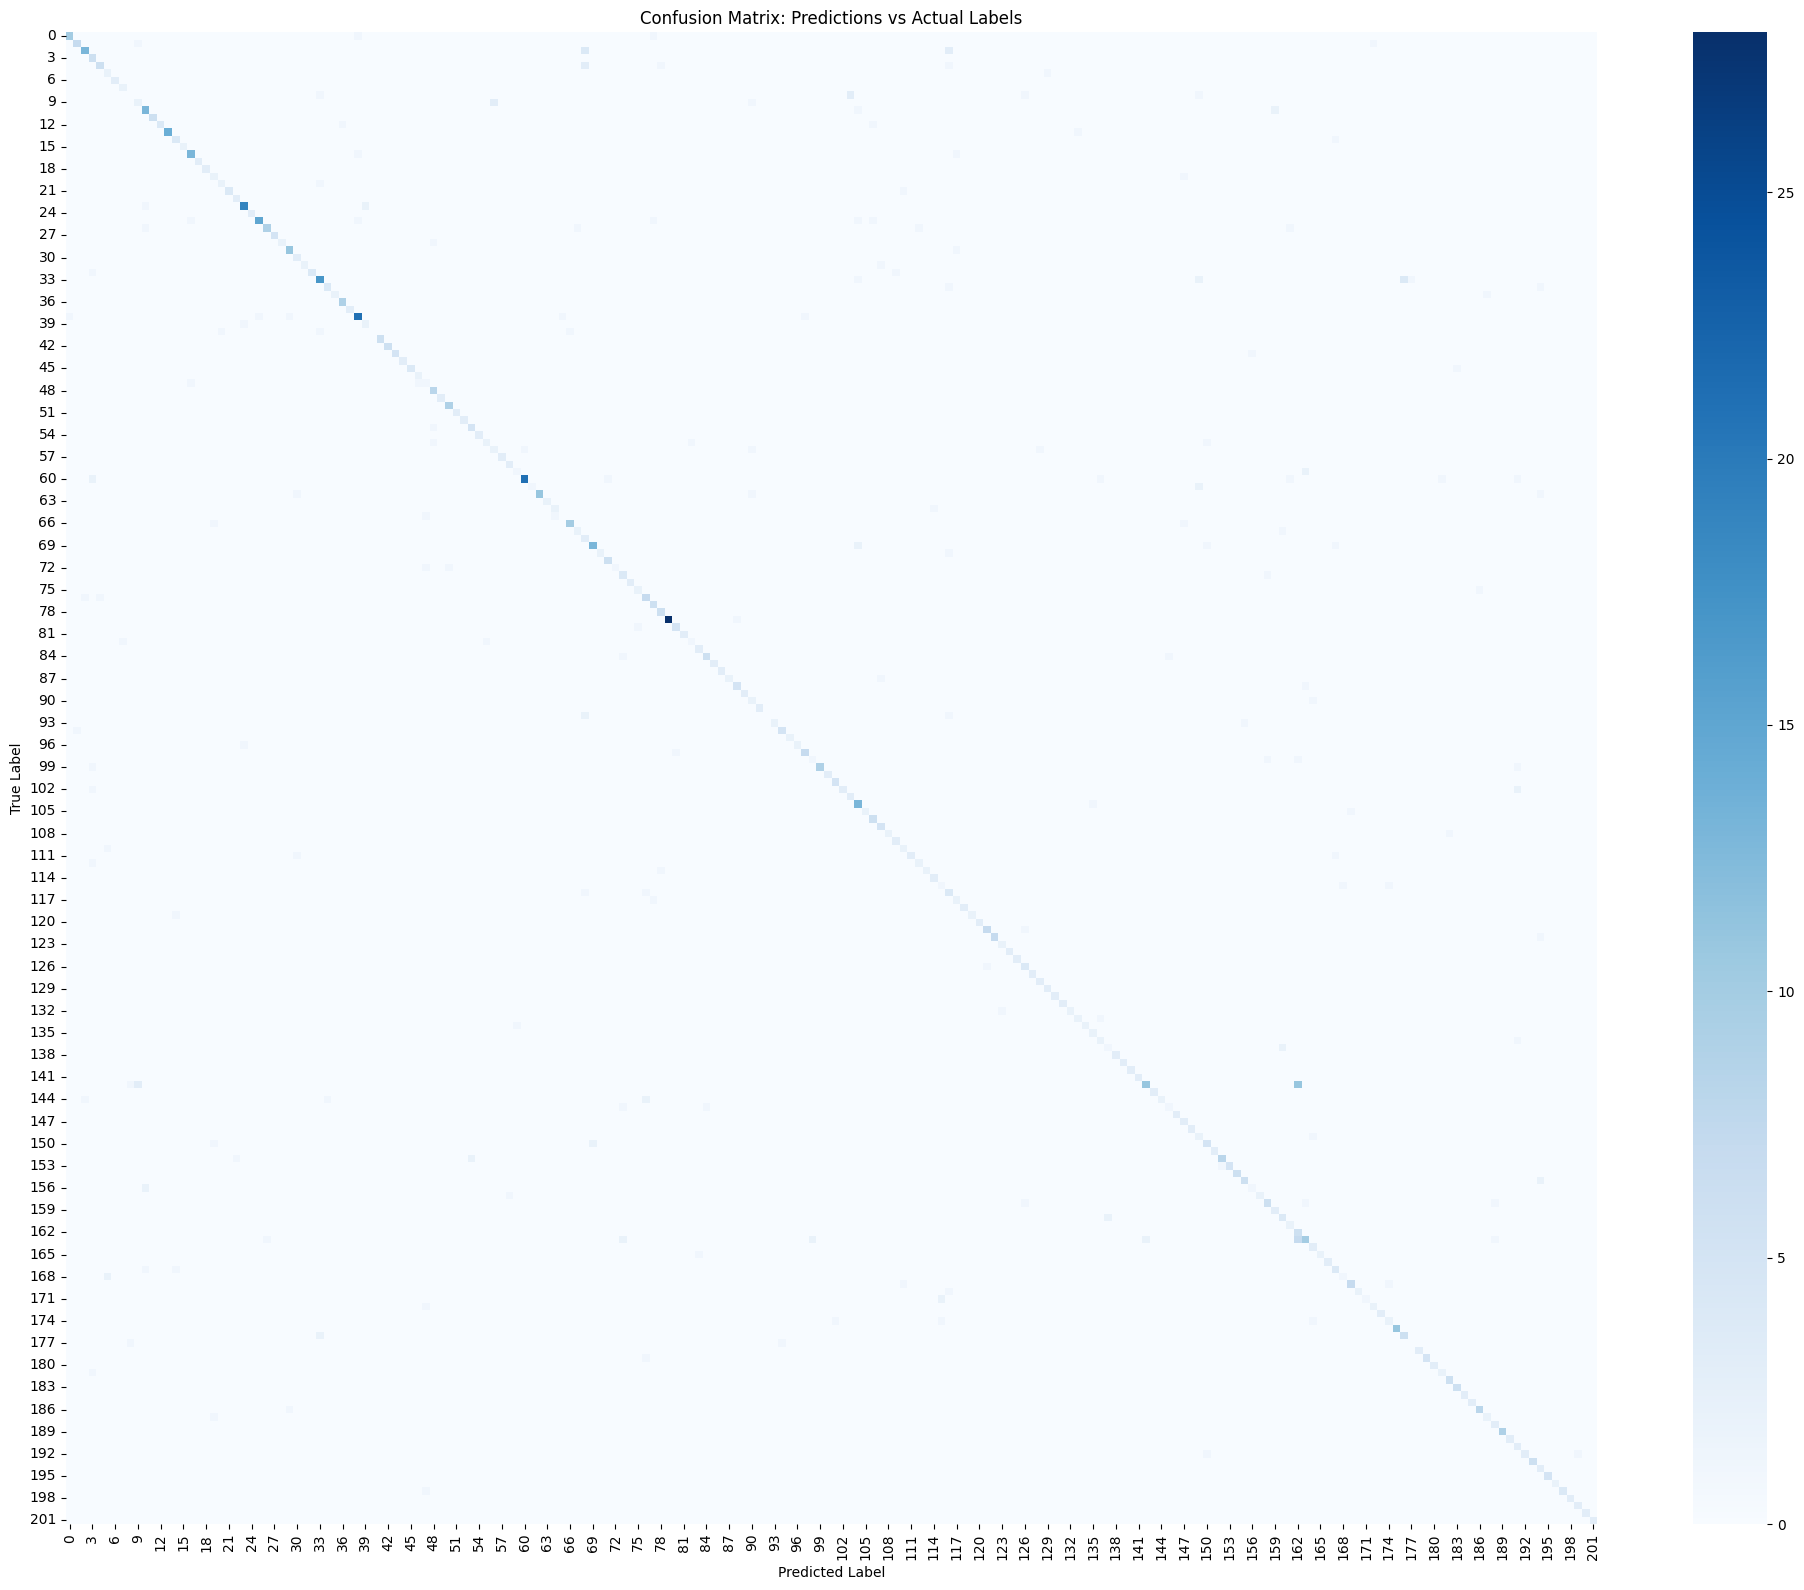

Confusion Matrix Shape: (202, 202)
Total Predictions: 1139


In [76]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix: Predictions vs Actual Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print shape and summary
print(f"Confusion Matrix Shape: {cm.shape}")
print(f"Total Predictions: {cm.sum()}")

In [ ]:
# y_pred_classes[1]
# test_generator.class_indices.items()

array([79, 79, 79, ..., 79, 79, 79], dtype=int64)